In [71]:
import pandas as pd
import numpy as np


In [72]:
df = pd.read_csv("/content/train.csv")

In [73]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [74]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [75]:
df.shape

(1460, 81)

In [76]:
df.dtypes


,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [77]:
cat=[]
num=[]
for col in df.columns:
  if df[col].dtypes == 'object':
    cat.append(col)
  if df[col].dtypes == 'int64' and 'float64':
    num.append(col)
print(len(cat))
print(len(num))

43
35


In [78]:
a = df.describe().T.sort_values(by='std',ascending = False)
print(a.head(3))


            count           mean           std      min       25%       50%  \
SalePrice  1460.0  180921.195890  79442.502883  34900.0  129975.0  163000.0   
LotArea    1460.0   10516.828082   9981.264932   1300.0    7553.5    9478.5   
GrLivArea  1460.0    1515.463699    525.480383    334.0    1129.5    1464.0   

                 75%       max  
SalePrice  214000.00  755000.0  
LotArea     11601.50  215245.0  
GrLivArea    1776.75    5642.0  


In [79]:
p = df.isnull().sum()
pm = p/len(df)*100
pm5 = pm[pm>5]
pms = pm5.sort_values(ascending = False)
pms.head(3)


,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123


In [80]:
gt40_null = pm[pm>40].index
df.drop(gt40_null,axis = 1,inplace = True)

In [81]:
df.shape

(1460, 75)

In [82]:
ct = df.select_dtypes(include = 'object').columns
nm = df.select_dtypes(include = 'number').columns

for col in ct:
  df[col].fillna(df[col].mode()[0], inplace= True)
for col in nm:
  df[col].fillna(df[col].median(),inplace = True)

/tmp/ipykernel_1746/4149720127.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace= True)
/tmp/ipykernel_1746/4149720127.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [83]:
df.isnull().sum().sum()

np.int64(0)

In [84]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

oe = OrdinalEncoder()
en_col = df[['ExterQual','BsmtQual', 'KitchenQual', 'HeatingQC']]
fit_en = oe.fit_transform(en_col)
fit_en = pd.DataFrame(fit_en)
fit_en.head()


,0,1,2,3
0,2.0,2.0,2.0,0.0
1,3.0,2.0,3.0,0.0
2,2.0,2.0,2.0,0.0
3,3.0,3.0,2.0,2.0
4,2.0,2.0,2.0,0.0


In [85]:
oh = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
oh_col = df[['Neighborhood','SaleType','MSZoning']]
fit_oh = oh.fit_transform(oh_col)
fit_oh = pd.DataFrame(fit_oh)
fit_oh.head()


,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [86]:
#TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF.

df['TotalSF'] = (df['TotalBsmtSF'] + df['1stFlrSF']+df['2ndFlrSF'])
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2,2008,WD,Normal,208500,2566
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,5,2007,WD,Normal,181500,2524
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,9,2008,WD,Normal,223500,2706
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,2,2006,WD,Abnorml,140000,2473
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,12,2008,WD,Normal,250000,3343


In [87]:
#HouseAge = YrSold - YearBuilt.
df['HouseAge'] = df['YrSold']- df['YearBuilt']
df['IsRemodelled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,HouseAge,IsRemodelled
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,2,2008,WD,Normal,208500,2566,5,0
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,5,2007,WD,Normal,181500,2524,31,0
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,9,2008,WD,Normal,223500,2706,7,1
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,0,0,2,2006,WD,Abnorml,140000,2473,91,1
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,12,2008,WD,Normal,250000,3343,8,0


In [88]:
import seaborn as sns
import matplotlib.pyplot as plt


In [89]:
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['GrLivArea'] >= Q1 - 1.5*IQR) & (df['GrLivArea'] <= Q3 + 1.5*IQR)]

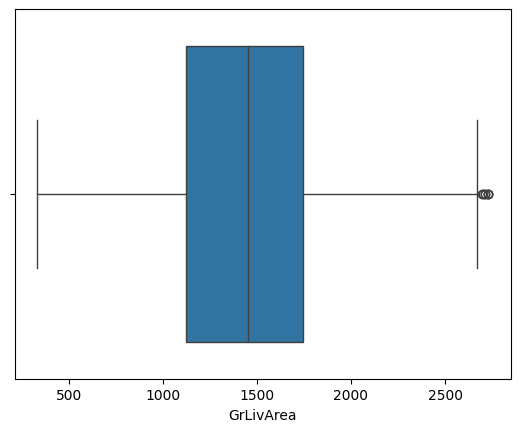

In [90]:
fig, ax = plt.subplots()
sns.boxplot(data = df, x='GrLivArea', ax=ax)
plt.show()

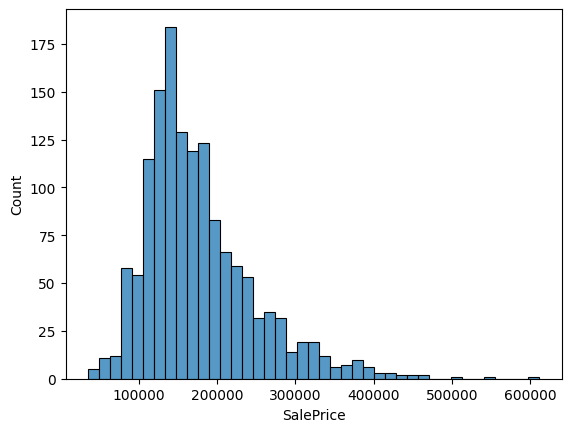

In [91]:
fig , ax = plt.subplots()
sns.histplot(data= df,x = 'SalePrice', ax = ax)
plt.show()


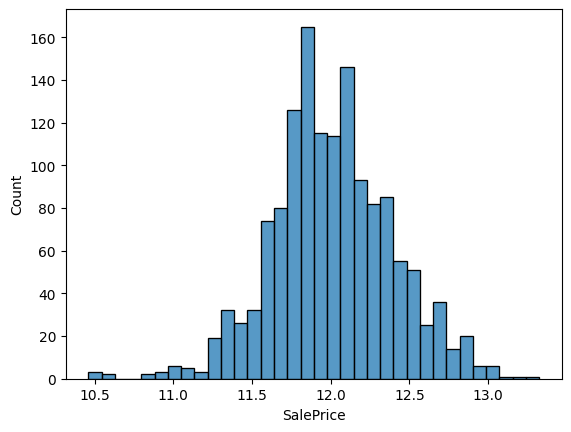

In [92]:
df['SalePrice'] = np.log(df['SalePrice'])
fig,ax = plt.subplots()
sns.histplot(data = df, x = 'SalePrice',ax = ax)
plt.show()



In [93]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import numpy as np

# y is already correctly derived from the filtered df
y = np.log1p(df['SalePrice'])

# Create a temporary DataFrame for feature processing (from the filtered df)
X_temp = df.drop(columns=['SalePrice', 'Id']) # Drop 'Id' directly

# Define columns for Ordinal and OneHot encoding
ordinal_cols = ['ExterQual', 'BsmtQual', 'KitchenQual', 'HeatingQC']
onehot_cols = ['Neighborhood', 'SaleType', 'MSZoning']

# Ordinal Encoding
oe = OrdinalEncoder()
# Check if ordinal_cols exist in X_temp
existing_ordinal_cols = [col for col in ordinal_cols if col in X_temp.columns]
if existing_ordinal_cols:
    X_ordinal_encoded = oe.fit_transform(X_temp[existing_ordinal_cols])
    X_ordinal_encoded = pd.DataFrame(X_ordinal_encoded, columns=existing_ordinal_cols, index=X_temp.index)
    X_temp = X_temp.drop(columns=existing_ordinal_cols)
else:
    X_ordinal_encoded = pd.DataFrame(index=X_temp.index) # Empty DataFrame if no columns

# One-Hot Encoding for specified columns
oh_specific = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
# Check if onehot_cols exist in X_temp
existing_onehot_cols = [col for col in onehot_cols if col in X_temp.columns]
if existing_onehot_cols:
    X_onehot_specific_encoded = oh_specific.fit_transform(X_temp[existing_onehot_cols])
    X_temp = X_temp.drop(columns=existing_onehot_cols)
else:
    X_onehot_specific_encoded = pd.DataFrame(index=X_temp.index) # Empty DataFrame if no columns

# Identify and One-Hot encode any *remaining* categorical columns
remaining_categorical_cols = X_temp.select_dtypes(include='object').columns.tolist()
if remaining_categorical_cols:
    oh_remaining = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
    X_remaining_cat_encoded = oh_remaining.fit_transform(X_temp[remaining_categorical_cols])
    X_temp = X_temp.drop(columns=remaining_categorical_cols)
else:
    X_remaining_cat_encoded = pd.DataFrame(index=X_temp.index) # Empty DataFrame if no columns

# Concatenate all processed features to form the final X
X = pd.concat([X_temp, X_ordinal_encoded, X_onehot_specific_encoded, X_remaining_cat_encoded], axis=1)

# Ensure all column names are strings for StandardScaler in subsequent steps
X.columns = X.columns.astype(str)

In [94]:
from sklearn.preprocessing import StandardScaler
import numpy as np

numerical_cols = X.select_dtypes(include=np.number).columns
X_numerical = X[numerical_cols]

# Convert column names to strings to resolve TypeError
X_numerical.columns = X_numerical.columns.astype(str)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)

print("Mean of column 1:", X_scaled[:, 0].mean())
print("Std of column 1:", X_scaled[:, 0].std())
print("Mean of column 2:", X_scaled[:, 1].mean())
print("Std of column 2:", X_scaled[:, 1].std())

Mean of column 1: -4.847999771631194e-17
Std of column 1: 1.0
Mean of column 2: -2.3867075798799725e-16
Std of column 2: 0.9999999999999999


In [95]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply StandardScaler to X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use transform for test set

# Convert scaled arrays back to DataFrames with original column names and index
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1143, 254)
X_test shape: (286, 254)
y_train shape: (1143,)
y_test shape: (286,)


In [96]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LR_pred = model.predict(X_test)

print(LR_pred)

[2.52895438 2.54169621 2.56401102 2.53911538 2.60969791 2.53324512
 2.55067199 2.57983306 2.54238619 2.56572877 2.55039795 2.52879043
 2.58524097 2.52070607 2.60280817 2.55352171 2.56710308 2.53840369
 2.56936934 2.54792557 2.51518805 2.610409   2.57844613 2.59548944
 2.54254021 2.57780427 2.54638841 2.5488471  2.54862034 2.55688072
 2.53765893 2.54914541 2.57912582 2.50739418 2.57577302 2.58791244
 2.5545092  2.53772684 2.6065261  2.57505362 2.61773195 2.55868419
 2.5533598  2.54310484 2.56270755 2.54473163 2.5171597  2.55204113
 2.49293256 2.63647193 2.55204763 2.54734719 2.56858793 2.56911989
 2.56755843 2.56900076 2.53821111 2.55727501 2.54026502 2.56714919
 2.5686801  2.58044119 2.55490271 2.54967691 2.57039475 2.55766752
 2.55921327 2.58428746 2.51558832 2.5625198  2.58477996 2.57621064
 2.55654657 2.61110903 2.5697122  2.59570663 2.53020156 2.55216994
 2.5373175  2.58691429 2.57494095 2.56023793 2.57219512 2.61803739
 2.57520655 2.55028444 2.58311    2.57588387 2.5887596  2.5561

In [97]:
from sklearn.tree import DecisionTreeRegressor

# Train
model = DecisionTreeRegressor(max_depth=5)
model.fit(X_train, y_train)

# Predict
DTR_pred = model.predict(X_test)

In [98]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Make predictions
RFR_pred = rf_regressor.predict(X_test)

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Import numpy for np.sqrt()

# Assuming you have:
# y_test: true values
# model1_pred, model2_pred, model3_pred: predictions from each model

metrics = []

for name, pred in [('LinearRegression',LR_pred), ('DecisionTreeRegressor', DTR_pred), ('RandomForestRegressor', RFR_pred)]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    metrics.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R-squared': r2})

metrics_df = pd.DataFrame(metrics)
metrics_df.set_index('Model', inplace=True)
print(metrics_df)

                            MAE      RMSE  R-squared
Model                                               
LinearRegression       0.006768  0.010068   0.879188
DecisionTreeRegressor  0.009617  0.014083   0.763613
RandomForestRegressor  0.006788  0.010332   0.872760


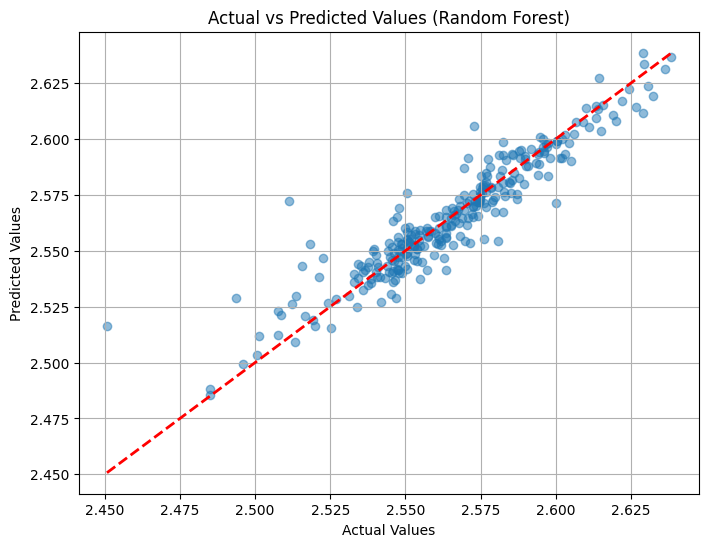

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, RFR_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Random Forest)')
plt.grid(True)
plt.show()

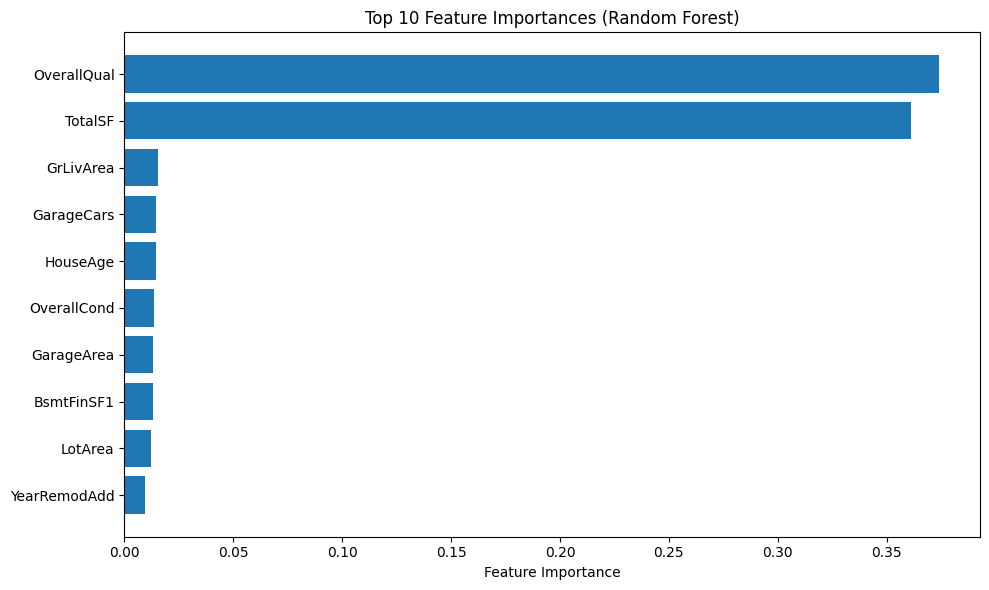

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'rf_regressor' is your trained Random Forest model
# and 'feature_names' contains your feature names
feature_importances = rf_regressor.feature_importances_
feature_names = X.columns # Define feature_names from the DataFrame's columns
sorted_idx = np.argsort(feature_importances)[::-1]  # Sort descending

# Get top 10 indices
top_10_idx = sorted_idx[:10]
top_10_importances = feature_importances[top_10_idx]
top_10_features = [feature_names[i] for i in top_10_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_10_features)), top_10_importances, align='center')
plt.yticks(range(len(top_10_features)), top_10_features)
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()  # Most important on top
plt.tight_layout()
plt.show()

### Best Performing Model
 
 Based on the evaluation metrics, **Linear Regression** performed best overall. It achieved the lowest MAE (**0.006768**) and lowest RMSE (**0.010068**), meaning its predictions had the smallest average and squared prediction errors among the tested models. It also had the highest R-squared value (**0.879188**), so it explained the largest proportion of variation in the target variable.
 
 The Random Forest Regressor was close, with MAE **0.006788**, RMSE **0.010332**, and R-squared **0.872760**, but Linear Regression was slightly better on all three metrics. The Decision Tree Regressor performed worst, with higher error values and a lower R-squared score.
